In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

benchmark = pd.read_csv(
    "../data/processed/benchmark_indices_clean.csv"
)

fund_master = pd.read_csv(
    "../data/processed/fund_master_clean.csv"
)

print(nav.shape)
print(benchmark.shape)
print(fund_master.shape)

(46000, 3)
(8050, 3)
(40, 15)


In [4]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [5]:
print("NAV Columns:")
print(nav.columns.tolist())

NAV Columns:
['amfi_code', 'date', 'nav']


In [6]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [7]:
# Sort data first
nav = nav.sort_values(
    ["amfi_code", "date"]
)

# Calculate daily returns for each fund
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Preview
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [8]:
# Basic statistics
print(nav["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


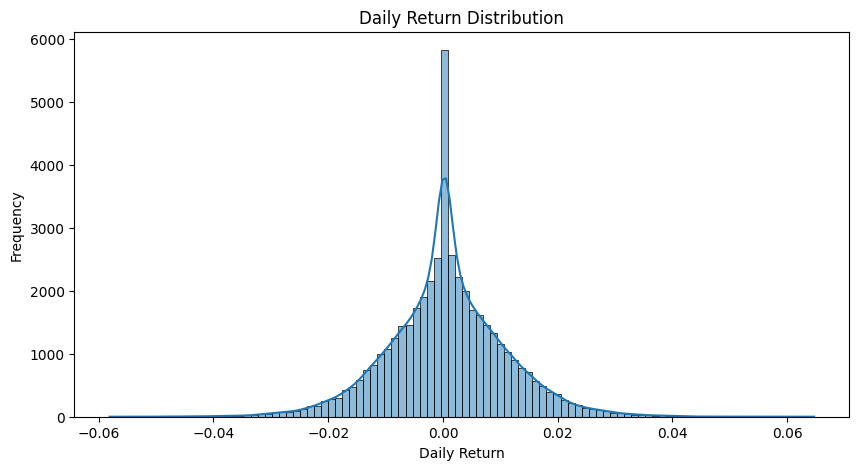

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title(
    "Daily Return Distribution"
)

plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

The distribution of daily returns is centered around zero and approximately bell-shaped, indicating that most mutual fund schemes experience small day-to-day fluctuations. Extreme positive and negative returns are relatively rare, validating the quality of the NAV dataset and daily return calculations.

In [11]:
def calculate_cagr(df, years):

    latest_date = df["date"].max()

    start_date = latest_date - pd.DateOffset(
        years=years
    )

    temp = df[df["date"] >= start_date]

    if len(temp) < 2:
        return None

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
        - 1
    )

    return cagr

In [ ]:
## Calculate CAGR for each fund and store in a list for creating a table later

cagr_data = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    try:

        cagr_data.append([
            fund,
            calculate_cagr(df, 1),
            calculate_cagr(df, 3),
            calculate_cagr(df, 5)
        ])

    except:
        pass

In [ ]:
## Create CAGR table from the calculated data 

cagr_table = pd.DataFrame(
    cagr_data,
    columns=[
        "amfi_code",
        "cagr_1y",
        "cagr_3y",
        "cagr_5y"
    ]
)

cagr_table.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [ ]:
## Convert to percentage and round

cagr_table["cagr_1y"] = (
    cagr_table["cagr_1y"] * 100
).round(2)

cagr_table["cagr_3y"] = (
    cagr_table["cagr_3y"] * 100
).round(2)

cagr_table["cagr_5y"] = (
    cagr_table["cagr_5y"] * 100
).round(2)

cagr_table.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
0,100016,-2.22,1.29,2.32
1,100025,3.70,3.92,3.91
2,100033,53.23,32.44,26.07
3,101206,47.92,28.97,20.44
4,101207,-23.99,-4.15,6.95


In [15]:
## Display top 10 funds by 5-year CAGR

top_10 = (
    cagr_table
    .sort_values(
        "cagr_5y",
        ascending=False
    )
    .head(10)
)

top_10

,amfi_code,cagr_1y,cagr_3y,cagr_5y
25,120505,29.60,31.78,28.38
21,119598,82.78,26.67,28.03
39,149324,65.14,27.00,27.92
36,148569,39.75,29.18,27.63
34,148567,20.36,34.00,26.80
30,120843,26.66,29.58,26.74
2,100033,53.23,32.44,26.07
38,149323,21.48,26.87,25.61
16,119094,22.26,35.11,24.45
19,119551,60.44,30.46,22.38


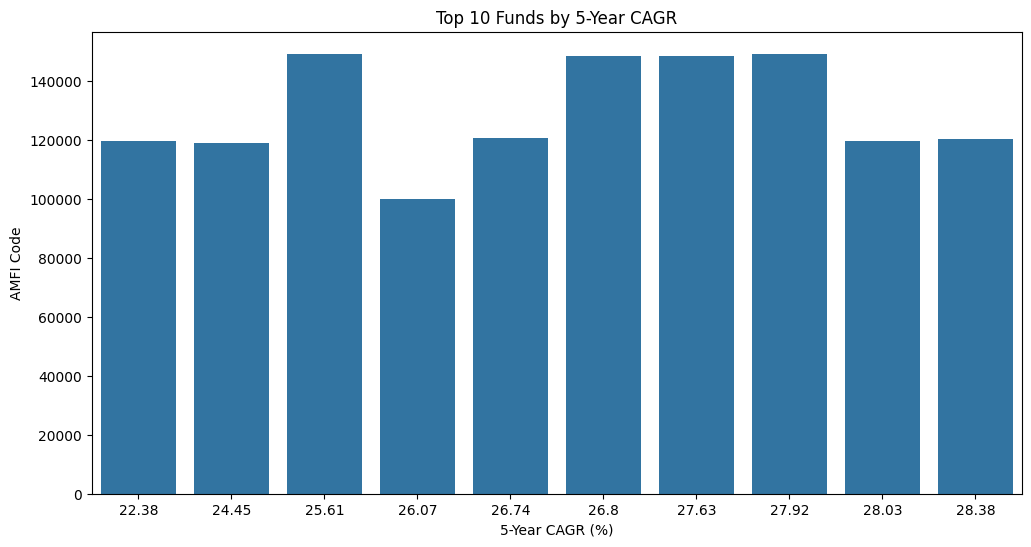

In [16]:
## Visualize top 10 funds by 5-year CAGR

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10,
    x="cagr_5y",
    y="amfi_code"
)

plt.title(
    "Top 10 Funds by 5-Year CAGR"
)

plt.xlabel("5-Year CAGR (%)")
plt.ylabel("AMFI Code")

plt.show()

CAGR analysis shows the annualized growth rate of each mutual fund over different investment horizons. The 5-year CAGR metric provides the most stable indicator of long-term performance, helping investors compare funds beyond short-term market fluctuations.

In [18]:
## Calculate Sharpe Ratio for each fund and store in a list for creating a table later

risk_free = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    returns = temp[
        "daily_return"
    ].dropna()

    if len(returns) > 0 and returns.std() != 0:

        sharpe = (
            (
                returns.mean()
                -
                risk_free / 252
            )
            /
            returns.std()
        ) * np.sqrt(252)

        sharpe_results.append(
            [fund, sharpe]
        )

In [ ]:
## Create Sharpe Ratio table from the calculated data

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)


sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [20]:
## Display top 10 funds by Sharpe Ratio

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


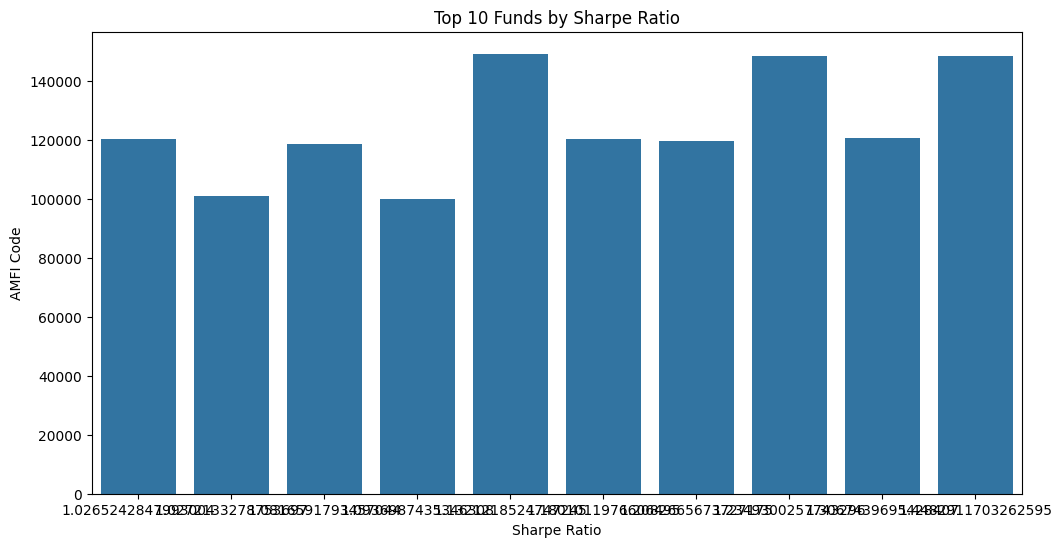

In [21]:
## Visualize top 10 funds by Sharpe Ratio

top_sharpe = (
    sharpe_df
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="amfi_code"
)

plt.title(
    "Top 10 Funds by Sharpe Ratio"
)

plt.xlabel("Sharpe Ratio")
plt.ylabel("AMFI Code")

plt.show()

Sharpe Ratio measures risk-adjusted returns by comparing excess returns over the risk-free rate against portfolio volatility. Higher Sharpe Ratios indicate better risk-adjusted performance. Funds with consistently strong returns and lower volatility rank higher, making them attractive for long-term investors.

In [23]:


sortino_results = []

for fund in nav["scheme_name"].unique():

    temp = nav[
        nav["scheme_name"] == fund
    ]

    returns = temp[
        "daily_return"
    ].dropna()

    downside = returns[
        returns < 0
    ]

    if len(downside) > 0:

        sortino = (
            (
                returns.mean()
                -
                risk_free/252
            )
            /
            downside.std()
        ) * np.sqrt(252)

        sortino_results.append(
            [fund,sortino]
        )

KeyError: 'scheme_name'

In [24]:
## Create Sortino Ratio table from the calculated data

sortino_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    returns = temp[
        "daily_return"
    ].dropna()

    downside = returns[
        returns < 0
    ]

    if len(downside) > 1 and downside.std() != 0:

        sortino = (
            (
                returns.mean()
                -
                risk_free / 252
            )
            /
            downside.std()
        ) * np.sqrt(252)

        sortino_results.append(
            [fund, sortino]
        )

In [25]:
## Create Sortino Ratio table from the calculated data

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [26]:
## Display top 10 funds by Sortino Ratio

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


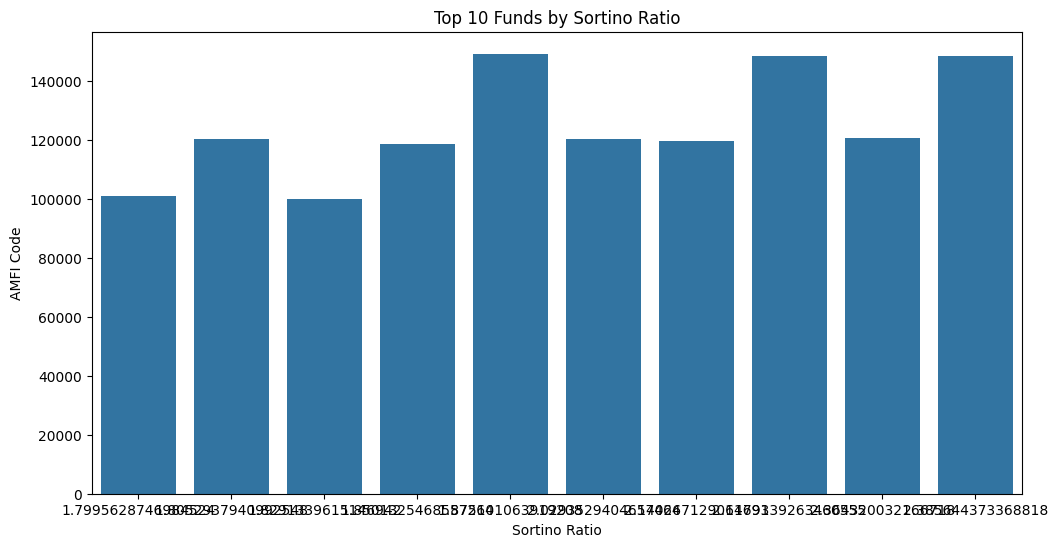

In [27]:
## Visualize top 10 funds by Sortino Ratio

top_sortino = (
    sortino_df
    .sort_values(
        "sortino_ratio",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sortino,
    x="sortino_ratio",
    y="amfi_code"
)

plt.title(
    "Top 10 Funds by Sortino Ratio"
)

plt.xlabel("Sortino Ratio")
plt.ylabel("AMFI Code")

plt.show()

The Sortino Ratio measures risk-adjusted returns while considering only downside volatility. Unlike the Sharpe Ratio, it ignores positive fluctuations and focuses solely on harmful volatility. A higher Sortino Ratio indicates that a fund generates stronger returns relative to downside risk, making it a valuable metric for evaluating long-term investment performance.

In [28]:
print(nav.columns.tolist())
print(benchmark.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']
['date', 'index_name', 'close_value']


In [ ]:
## Convert benchmark date to datetime

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark_nifty = benchmark[
    benchmark["index_name"] == "Nifty 100"
].copy()

benchmark_nifty = benchmark_nifty.sort_values(
    "date"
)

benchmark_nifty["benchmark_return"] = (
    benchmark_nifty["close_value"]
    .pct_change()
)

In [38]:
print(benchmark["index_name"].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [37]:
benchmark_nifty = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [39]:
benchmark_nifty = benchmark_nifty.sort_values(
    "date"
)

benchmark_nifty["benchmark_return"] = (
    benchmark_nifty["close_value"]
    .pct_change()
)

In [40]:
print(benchmark_nifty.shape)
benchmark_nifty.head()

(1150, 4)


,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [41]:
## Calculate alpha and beta for each fund using linear regression against the benchmark returns

from scipy.stats import linregress

alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_df,
        benchmark_nifty[
            ["date","benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 50:

        slope, intercept, r, p, se = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append(
            [fund, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

In [42]:
print(alpha_beta_df.shape)
alpha_beta_df.head()

(40, 3)


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [44]:
## Create alpha-beta table from the calculated data
alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


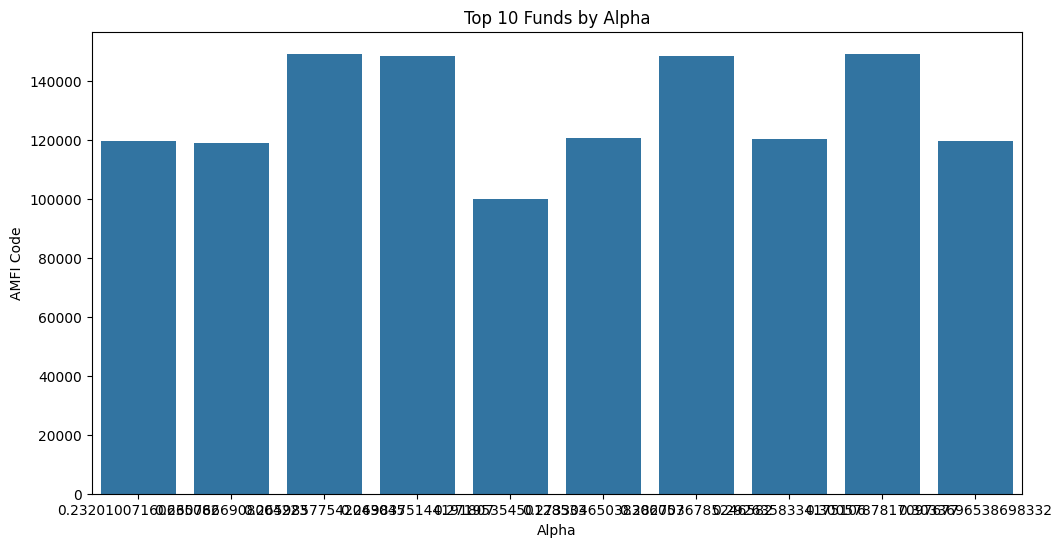

In [45]:
## Visualize top 10 funds by alpha
top_alpha = (
    alpha_beta_df
    .sort_values(
        "alpha",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_alpha,
    x="alpha",
    y="amfi_code"
)

plt.title(
    "Top 10 Funds by Alpha"
)

plt.xlabel("Alpha")
plt.ylabel("AMFI Code")

plt.show()

In [46]:
alpha_beta_df.describe()

,amfi_code,alpha,beta
count,40.000000,40.000000,40.000000
mean,120247.000000,0.159085,-0.001958
std,14534.998667,0.087528,0.035194
min,100016.000000,0.028969,-0.066951
25%,118632.750000,0.068612,-0.023937
50%,119551.500000,0.162326,-0.000067
75%,120842.250000,0.221723,0.017026
max,149324.000000,0.303370,0.103497


In [47]:
## Calculate maximum drawdown for each fund and store in a list for creating a table later

drawdowns = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values(
        "date"
    )

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        -
        1
    )

    max_dd = temp[
        "drawdown"
    ].min()

    drawdowns.append(
        [fund, max_dd]
    )

In [48]:
## Create drawdown table from the calculated data

drawdown_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [ ]:
drawdown_df["max_drawdown"] = (
    drawdown_df["max_drawdown"] * 100
).round(2)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-24.73
1,100025,-4.31
2,100033,-16.22
3,101206,-11.29
4,101207,-35.45


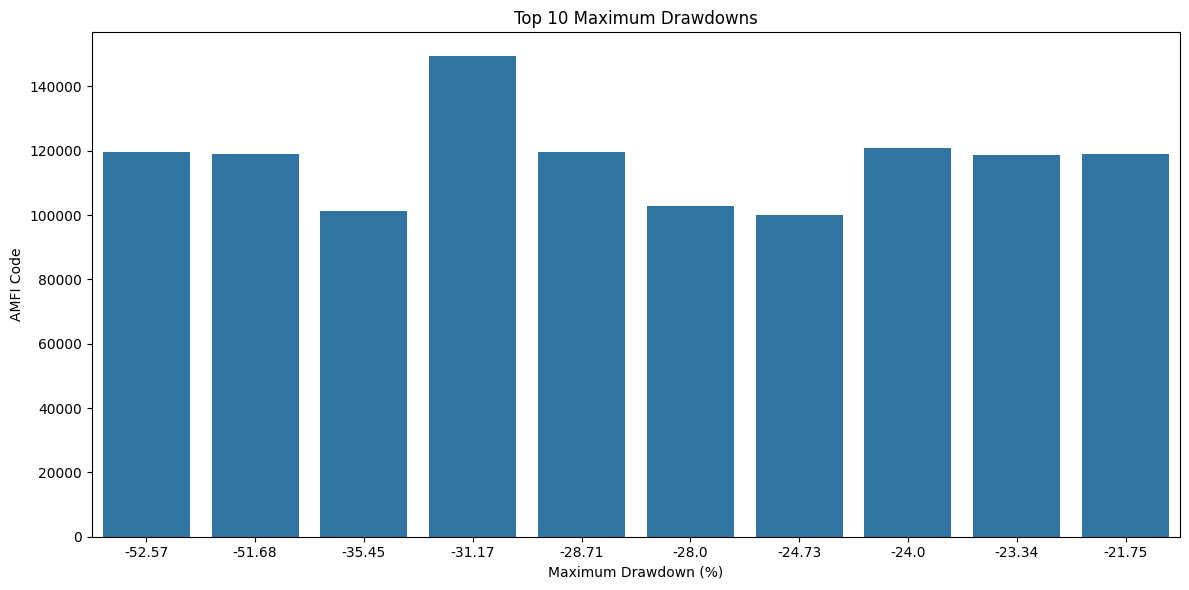

In [50]:

worst_dd = (
    drawdown_df
    .sort_values(
        "max_drawdown"
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_dd,
    x="max_drawdown",
    y="amfi_code"
)

plt.title(
    "Top 10 Maximum Drawdowns"
)

plt.xlabel("Maximum Drawdown (%)")
plt.ylabel("AMFI Code")

plt.tight_layout()

plt.show()

Maximum Drawdown measures the largest decline from a fund's historical peak value to its subsequent lowest point. It is an important risk metric that highlights potential losses investors could have experienced during adverse market conditions. Funds with smaller drawdowns are generally considered more resilient during market downturns.

In [ ]:
## Combine all performance metrics into a single scorecard table

scorecard = (
    cagr_table
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        drawdown_df,
        on="amfi_code"
    )
)

scorecard.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y,sharpe_ratio,scheme_name,alpha,beta,max_drawdown
0,100016,-2.22,1.29,2.32,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268,-24.73
1,100025,3.70,3.92,3.91,-0.567095,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158,-4.31
2,100033,53.23,32.44,26.07,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104,-16.22
3,101206,47.92,28.97,20.44,1.027213,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086,-11.29
4,101207,-23.99,-4.15,6.95,0.162661,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289,-35.45


In [53]:
## Rank funds based on each metric (higher is better for returns, Sharpe, alpha; lower is better for drawdown)

scorecard["return_rank"] = (
    scorecard["cagr_3y"]
    .rank(
        ascending=False
    )
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(
        ascending=False
    )
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(
        ascending=False
    )
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        ascending=True
    )
)

In [54]:
## Calculate a composite score by weighting each metric (weights can be adjusted based on preference)

scorecard["raw_score"] = (

    0.30 *
    scorecard["return_rank"]

    +

    0.25 *
    scorecard["sharpe_rank"]

    +

    0.20 *
    scorecard["alpha_rank"]

    +

    0.10 *
    scorecard["dd_rank"]

)

In [55]:
## Normalize the raw score to a 0-100 scale

scorecard["score"] = (
    100 *
    (
        scorecard["raw_score"]
        -
        scorecard["raw_score"].min()
    )
    /
    (
        scorecard["raw_score"].max()
        -
        scorecard["raw_score"].min()
    )
)

In [ ]:
## Invert score so that higher is better (since lower ranks are better)

scorecard["score"] = (
    100 - scorecard["score"]
).round(2)

In [58]:
print(scorecard.shape)
scorecard.head()

(40, 15)


,amfi_code,cagr_1y,cagr_3y,cagr_5y,sharpe_ratio,scheme_name,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,dd_rank,raw_score,score
0,100016,-2.22,1.29,2.32,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268,-24.73,35.0,35.0,39.0,7.0,27.75,13.31
1,100025,3.70,3.92,3.91,-0.567095,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158,-4.31,34.0,39.0,38.0,37.0,31.25,0.00
2,100033,53.23,32.44,26.07,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104,-16.22,4.0,7.0,6.0,21.0,6.25,95.06
3,101206,47.92,28.97,20.44,1.027213,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086,-11.29,9.0,9.0,12.0,32.0,10.55,78.71
4,101207,-23.99,-4.15,6.95,0.162661,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289,-35.45,39.0,28.0,27.0,3.0,24.40,26.05


In [60]:
top_funds = scorecard.sort_values(
    "score",
    ascending=False
).head(10)

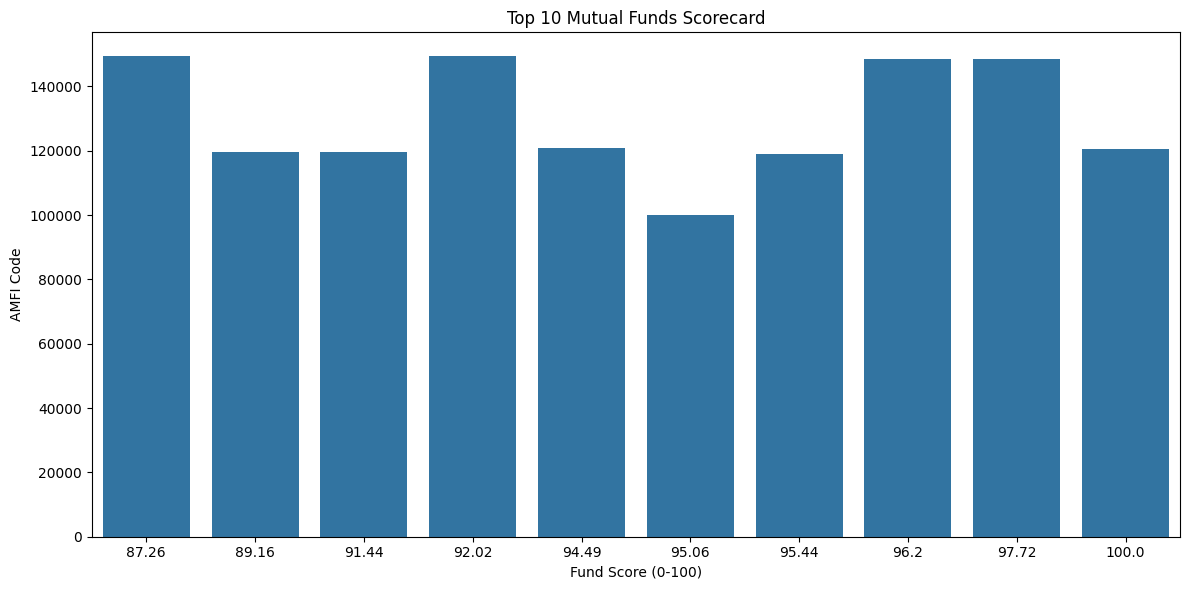

In [61]:
## Display top 10 funds by composite score

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x="score",
    y="amfi_code"
)

plt.title(
    "Top 10 Mutual Funds Scorecard"
)

plt.xlabel("Fund Score (0-100)")
plt.ylabel("AMFI Code")

plt.tight_layout()

plt.show()

The Fund Scorecard combines return, risk-adjusted performance, benchmark outperformance, and downside risk into a single normalized score ranging from 0 to 100. This composite ranking enables investors to compare mutual funds holistically rather than relying on a single performance metric.

In [62]:
top5 = (
    scorecard
    .sort_values(
        "score",
        ascending=False
    )
    [["amfi_code", "score",
      "cagr_3y",
      "sharpe_ratio",
      "alpha",
      "beta",
      "max_drawdown"]]
    .head(5)
)

top5

,amfi_code,score,cagr_3y,sharpe_ratio,alpha,beta,max_drawdown
25,120505,100.00,31.78,1.180101,0.292636,0.000549,-18.19
34,148567,97.72,34.00,1.448291,0.269838,0.023684,-11.27
36,148569,96.20,29.18,1.234930,0.282704,0.018134,-16.40
16,119094,95.44,35.11,0.998231,0.260767,-0.066265,-20.96
2,100033,95.06,32.44,1.093699,0.271954,0.005104,-16.22


Based on the composite scorecard methodology, the top 5 mutual funds demonstrate the strongest combination of long-term returns, risk-adjusted performance, benchmark outperformance, and downside protection. These funds rank highest across multiple performance dimensions and represent the best-performing schemes in the analyzed universe.

In [63]:
top5.to_csv(
    "../reports/top5_funds.csv",
    index=False
)

In [64]:
print("CAGR Table:", cagr_table.shape)
print("Sharpe:", sharpe_df.shape)
print("Sortino:", sortino_df.shape)
print("Alpha Beta:", alpha_beta_df.shape)
print("Drawdown:", drawdown_df.shape)
print("Scorecard:", scorecard.shape)
print("Top 5:", top5.shape)

CAGR Table: (40, 4)
Sharpe: (40, 3)
Sortino: (40, 2)
Alpha Beta: (40, 3)
Drawdown: (40, 2)
Scorecard: (40, 15)
Top 5: (5, 7)


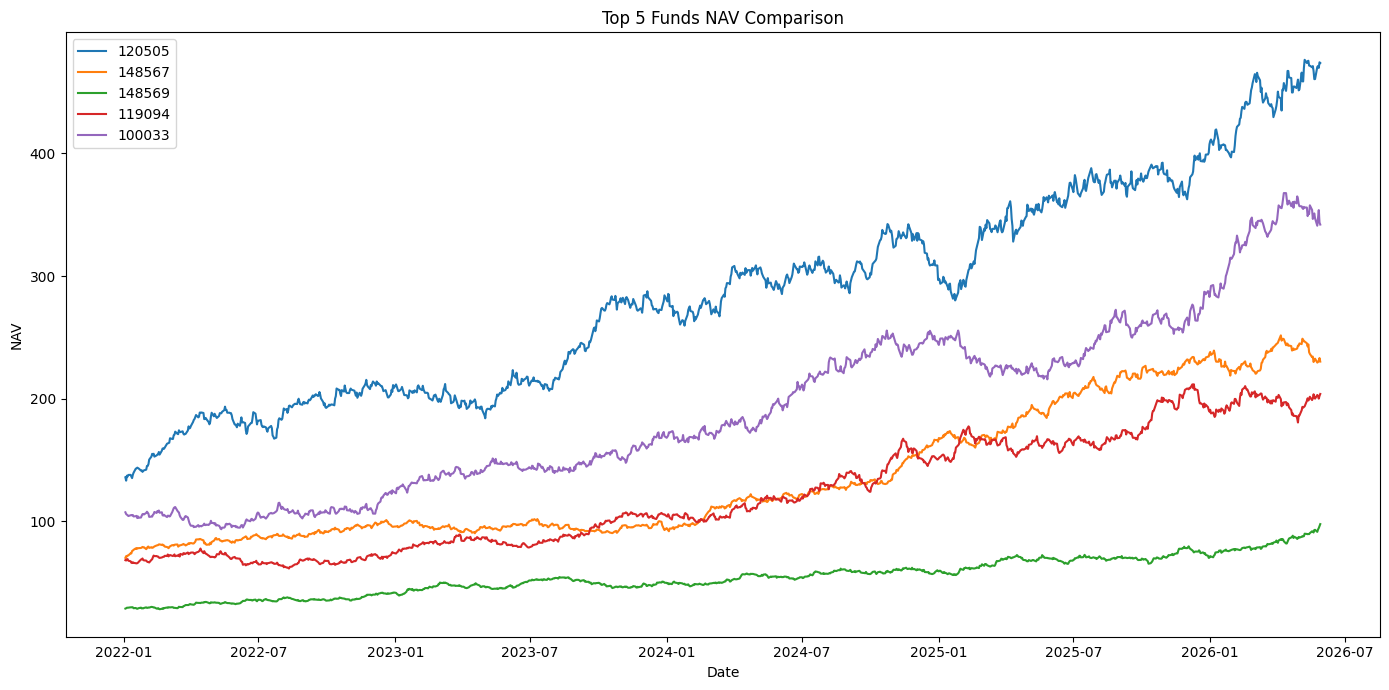

In [65]:
## Visualize NAV history of top 5 funds

plt.figure(
    figsize=(14,7)
)

for fund in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.legend()

plt.title(
    "Top 5 Funds NAV Comparison"
)

plt.xlabel("Date")
plt.ylabel("NAV")

plt.tight_layout()

plt.savefig(
    "../reports/top5_funds_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

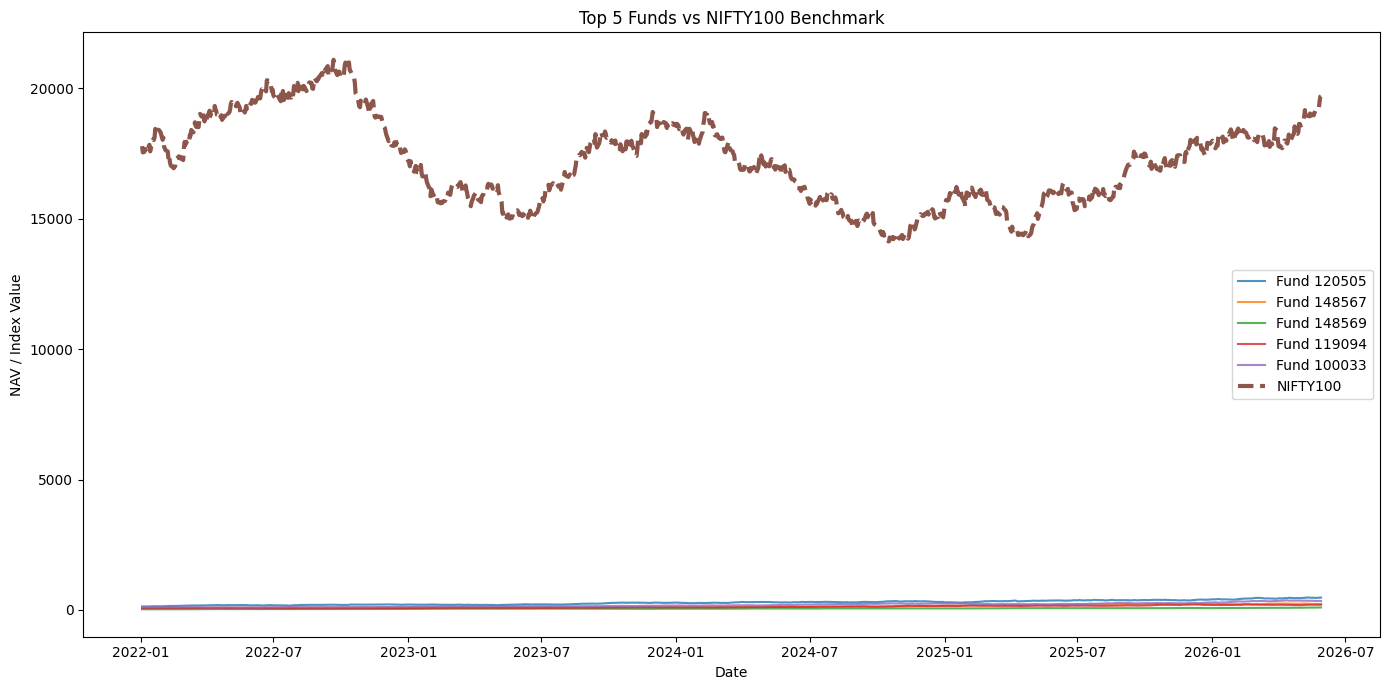

In [66]:
## Visualize NAV history of top 5 funds vs NIFTY100 benchmark

plt.figure(figsize=(14,7))

# Top 5 funds
for fund in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        alpha=0.8,
        label=f"Fund {fund}"
    )

# Benchmark
plt.plot(
    benchmark_nifty["date"],
    benchmark_nifty["close_value"],
    linewidth=3,
    linestyle="--",
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY100 Benchmark"
)

plt.xlabel("Date")
plt.ylabel("NAV / Index Value")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

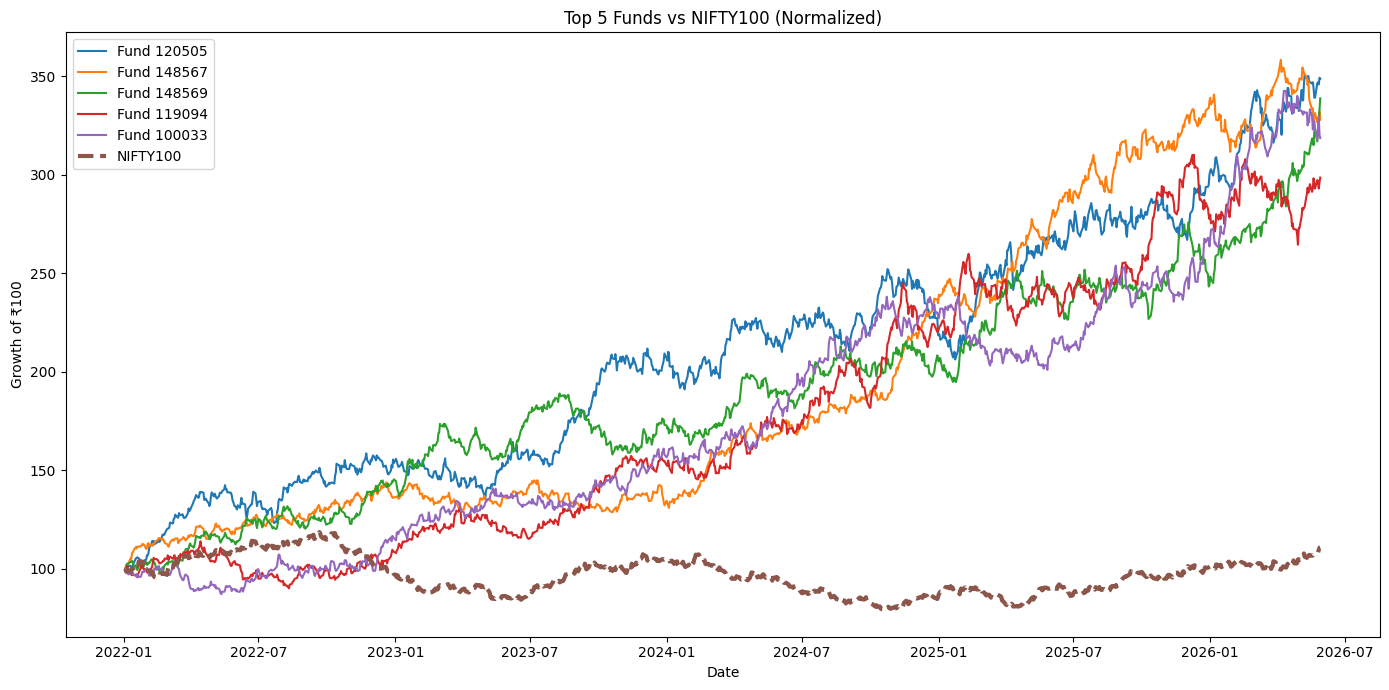

In [67]:
## Normalize NAV and benchmark to 100 at the start date for better visual comparison

plt.figure(figsize=(14,7))

for fund in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["normalized"] = (
        temp["nav"] /
        temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        label=f"Fund {fund}"
    )

benchmark_plot = benchmark_nifty.copy()

benchmark_plot["normalized"] = (
    benchmark_plot["close_value"] /
    benchmark_plot["close_value"].iloc[0]
) * 100

plt.plot(
    benchmark_plot["date"],
    benchmark_plot["normalized"],
    linewidth=3,
    linestyle="--",
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY100 (Normalized)"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹100")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()